In [2]:
!pip install noisereduce webrtcvad pydub librosa soundfile tqdm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.2/66.2 kB 2.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for webrtcvad: filename=webrtcvad-2.0.10-cp312-cp312-linux_x86_64.whl size=73512 sha256=bd7df948b491d0a093a4cc65aa4f8c019e69131dc3532637c0d4230add9536dd
  Stored in directory: /root/.cache/pip/wheels/1e/d3/95/680fa3b16848f1a58d2edaed34c496224c89a9bc63e17b3614
Successfully built webrtcvad


In [37]:
import os
import pandas as pd
import numpy as np
import librosa
import soundfile as sf
import noisereduce as nr
import webrtcvad
from tqdm import tqdm
from pydub import AudioSegment
import random
import re
import matplotlib.pyplot as plt
import IPython.display as ipd

In [38]:
input_folder = "/kaggle/input/datasets/majdomari4/irbid4/irbidoxg"  # مجلد الملفات الصوتية
output_folder = "/kaggle/working/cleaned_irbid_audio"  # هنا الملفات بعد المعالجة
os.makedirs(output_folder, exist_ok=True)

In [39]:
text_path = "/kaggle/input/datasets/majdomari4/irbid4/Irbid_Text (1).xlsx" 
output_text_path = "/kaggle/working/irbi_data.xlsx"

In [40]:
df = pd.read_excel(text_path)
print(df.head())

  Arbicsentence  length   IrbidDialect  ID
0     خرج سامي.       2      طلع سامي.   1
1    كذب علينا.       2     كذب علينا.   2
2     لم يقترب.       2       ما قرّب.   3
3      ليث انسب       2       ليث أنسب   4
4    إعرف نفسك!       2  عرّف عن حالك!   5


In [42]:
def purge_temps(folder):
    temps = [f for f in os.listdir(folder) if f.startswith("temp_")]
    for f in temps:
        os.remove(os.path.join(folder, f))
    if temps:
        print(f" Cleaned up {len(temps)} old temporary files.")

# Pre-run cleanup
purge_temps(output_folder)

In [43]:
def get_all_files(folder):
    return [f for f in os.listdir(folder) if os.path.isfile(os.path.join(folder, f)) and not f.startswith('.')]

audio_files = get_all_files(input_folder)
print(f" Found {len(audio_files)} source files.")


 Found 1500 source files.


In [44]:
vad = webrtcvad.Vad(1)
def has_speech(audio_data, sample_rate):
    audio_int16 = (audio_data * 32767).astype(np.int16).tobytes()
    frame_duration = 30
    frame_size = int(sample_rate * frame_duration / 1000) * 2
    for i in range(0, len(audio_int16) - frame_size, frame_size):
        if vad.is_speech(audio_int16[i : i + frame_size], sample_rate):
            return True
    return False

def convert_any_to_wav(input_path, output_path):
    try:
        audio = AudioSegment.from_file(input_path)
        audio = audio.set_channels(1).set_frame_rate(16000)
        audio.export(output_path, format="wav")
        return True
    except:
        try:
            audio = AudioSegment.from_file(input_path, format="ogg")
            audio = audio.set_channels(1).set_frame_rate(16000)
            audio.export(output_path, format="wav")
            return True
        except:
            return False

def process_and_clean(filename):
    input_path = os.path.join(input_folder, filename)
    clean_base_name = os.path.splitext(filename)[0]
    temp_wav = os.path.join(output_folder, f"temp_{clean_base_name}.wav")
    final_wav = os.path.join(output_folder, f"{clean_base_name}.wav")
    if not convert_any_to_wav(input_path, temp_wav):
        return "failed"

    try:
        y, sr = librosa.load(temp_wav, sr=16000)

        if not has_speech(y, sr):
            if os.path.exists(temp_wav): os.remove(temp_wav)
            return "no_speech"

        noise_sample = y[:int(0.5 * sr)] if len(y) > int(0.5 * sr) else y
        y_denoised = nr.reduce_noise(y=y, y_noise=noise_sample, sr=sr)

        y_trimmed, _ = librosa.effects.trim(y_denoised, top_db=25)

        sf.write(final_wav, y_trimmed, sr)

        if os.path.exists(temp_wav): os.remove(temp_wav)
        return "success"
    except:
        if os.path.exists(temp_wav): os.remove(temp_wav)
        return "error"

In [28]:
for filename in tqdm(audio_files, desc="Processing Audio"):
    process_and_clean(filename)

# Final Post-run cleanup just in case
purge_temps(output_folder)

# Final Count Verification
output_files = [f for f in os.listdir(output_folder) if f.endswith(".wav")]
print(f"\n--- Final Report ---")
print(f"Original Files: {len(audio_files)}")
print(f"Processed Files: {len(output_files)}")
if len(audio_files) != len(output_files):
    print(f" Note: {len(audio_files) - len(output_files)} files were skipped because they contained no speech.")

Processing Audio: 100%|██████████| 1500/1500 [05:52<00:00,  4.25it/s]


--- Final Report ---
Original Files: 1500
Processed Files: 1500



 ANALYSIS & PLAYBACK FOR: 1191


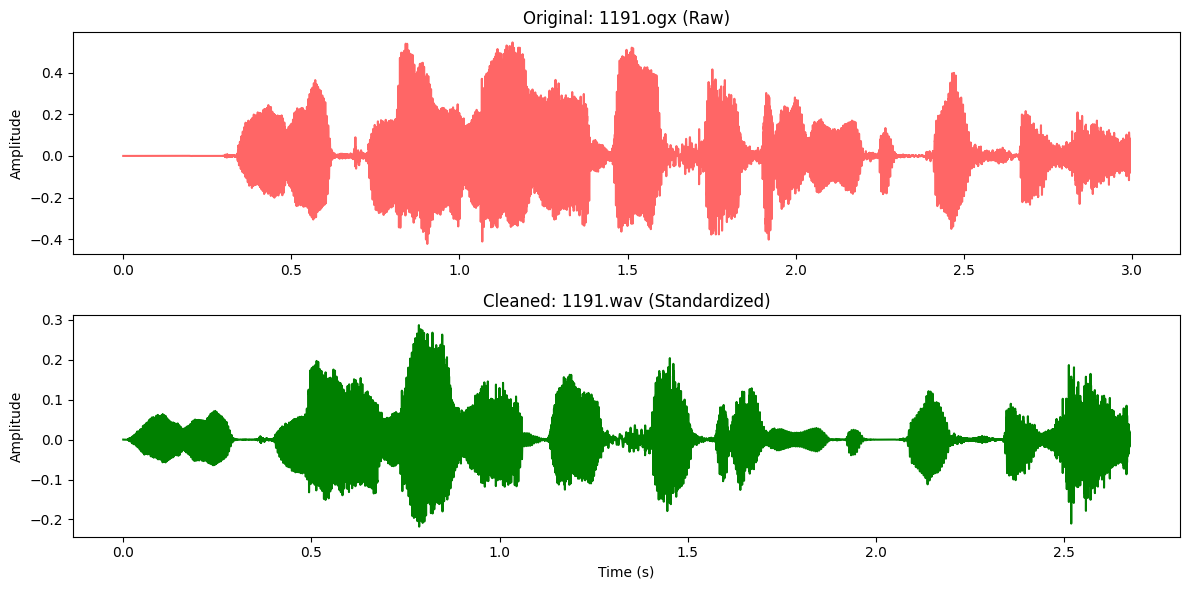

 Listen to Original (1191.ogx):


 Listen to Cleaned (1191.wav):





 ANALYSIS & PLAYBACK FOR: 1302


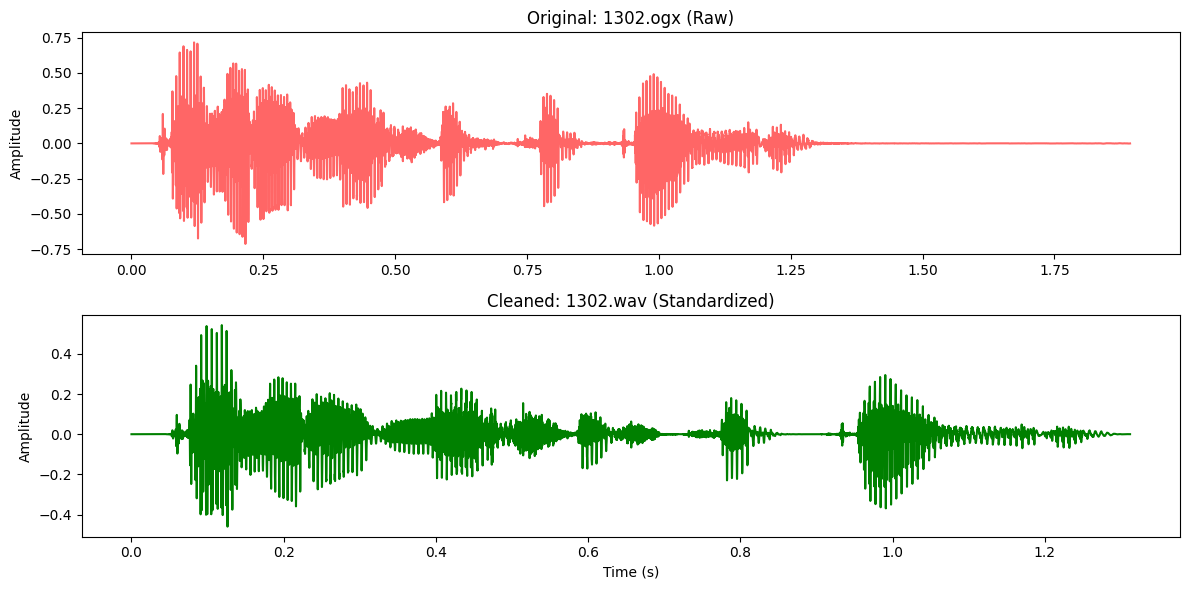

 Listen to Original (1302.ogx):


 Listen to Cleaned (1302.wav):


In [45]:
success_files = []
for f in audio_files:
    clean_name = os.path.splitext(f)[0] + ".wav"
    if os.path.exists(os.path.join(output_folder, clean_name)):
        success_files.append(f)

if not success_files:
    print(" No processed files found in the output folder.")
else:
    # 2. Pick 2 random samples
    samples_to_show = random.sample(success_files, min(len(success_files), 2))

    for filename in samples_to_show:
        clean_base = os.path.splitext(filename)[0]
        original_path = os.path.join(input_folder, filename)
        cleaned_path = os.path.join(output_folder, clean_base + ".wav")

        print("\n" + "="*80)
        print(f" ANALYSIS & PLAYBACK FOR: {clean_base}")
        print("="*80)

        try:
            # --- PART 1: VISUALIZATION ---
            y_old, sr_old = librosa.load(original_path, sr=16000)
            y_new, sr_new = librosa.load(cleaned_path, sr=16000)

            fig, ax = plt.subplots(nrows=2, sharex=False, figsize=(12, 6))

            # Original Plot (Red)
            ax[0].plot(np.linspace(0, len(y_old)/sr_old, len(y_old)), y_old, color='red', alpha=0.6)
            ax[0].set_title(f"Original: {filename} (Raw)")
            ax[0].set_ylabel("Amplitude")

            # Cleaned Plot (Green)
            ax[1].plot(np.linspace(0, len(y_new)/sr_new, len(y_new)), y_new, color='green')
            ax[1].set_title(f"Cleaned: {clean_base}.wav (Standardized)")
            ax[1].set_xlabel("Time (s)")
            ax[1].set_ylabel("Amplitude")

            plt.tight_layout()
            plt.show()

            # --- PART 2: AUDIO PLAYBACK ---
            print(f" Listen to Original ({filename}):")
            display(ipd.Audio(original_path, rate=16000))

            print(f" Listen to Cleaned ({clean_base}.wav):")
            display(ipd.Audio(cleaned_path))
            print("\n")

        except Exception as e:
            print(f" Could not process sample {filename}: {e}")

In [46]:
text_column = "IrbidDialect"
def normalize_arabic(text):
    text = str(text)
    text = re.sub(r'[\u0617-\u061A\u064B-\u0652]', '', text)
    text = re.sub(r"[إأآا]", "ا", text)
    text = re.sub(r"ى", "ي", text)
    text = re.sub(r"ؤ", "و", text)
    text = re.sub(r"ئ", "ي", text)
    text = re.sub(r"ة", "ه", text)
    text = re.sub(r"[^ء-ي\s]", "", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

df[text_column] = df[text_column].astype(str).apply(normalize_arabic)
df["audio_path"] = df["ID"].apply(
    lambda x: f"/kaggle/working/cleaned_irbid_audio/{int(x)}.wav" if pd.notna(x) else None
)
df["audio_exists"] = df["audio_path"].apply(
    lambda path: os.path.exists(path) if pd.notna(path) else False
)
df = df[df["audio_exists"] == True].reset_index(drop=True)
print(df.head())


  Arbicsentence  length IrbidDialect  ID  \
0     خرج سامي.       2     طلع سامي   1   
1    كذب علينا.       2    كذب علينا   2   
2     لم يقترب.       2       ما قرب   3   
3      ليث انسب       2     ليث انسب   4   
4    إعرف نفسك!       2  عرف عن حالك   5   

                                  audio_path  audio_exists  
0  /kaggle/working/cleaned_irbid_audio/1.wav          True  
1  /kaggle/working/cleaned_irbid_audio/2.wav          True  
2  /kaggle/working/cleaned_irbid_audio/3.wav          True  
3  /kaggle/working/cleaned_irbid_audio/4.wav          True  
4  /kaggle/working/cleaned_irbid_audio/5.wav          True  


In [47]:
output_text_path = "/kaggle/working/Irbid_data.xlsx"


folder_path = os.path.dirname(output_text_path)
if not os.path.exists(folder_path):
    os.makedirs(folder_path)

df.to_excel(output_text_path, index=False)

print(f"The new file has been saved to: {output_text_path}")

The new file has been saved to: /kaggle/working/Irbid_data.xlsx


In [48]:
import shutil

shutil.make_archive("/kaggle/working/cleaned_irbid_audio", 'zip', "/kaggle/working/cleaned_irbid_audio")
print("Folder has been zipped!")


from IPython.display import FileLink

# رابط لتحميل ZIP
FileLink("/kaggle/working/cleaned_irbid_audio.zip")

Folder has been zipped!


/kaggle/working/cleaned_irbid_audio.zip